In [3]:
import os 
from pathlib import Path

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from helper import * 

from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.metrics import recall_score, accuracy_score, f1_score, roc_auc_score, roc_curve, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb

current_dir = Path.cwd()  
PROJECT_ROOT = current_dir.parent.parent

df = pd.read_csv(PROJECT_ROOT/'data'/'processed'/'Cleaned_csv.csv')

df = df.drop(labels=['Unnamed: 0'], axis=1)
df = df.rename(columns=lambda x: x.replace('remainder__', ''))
df.head()

,encoder__City_Los Angeles,encoder__City_Other,encoder__City_San Diego,encoder__City_San Francisco,encoder__Gender_Female,encoder__Gender_Male,encoder__Senior Citizen_No,encoder__Senior Citizen_Yes,encoder__Dependents_No,encoder__Dependents_Yes,...,encoder__Paperless Billing_Yes,encoder__Payment Method_Bank transfer (automatic),encoder__Payment Method_Credit card (automatic),encoder__Payment Method_Electronic check,encoder__Payment Method_Mailed check,Tenure Months,Monthly Charges,Total Charges,Churn Value,CLTV
0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,2.0,53.85,108.15,1.0,3239.0
1,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,2.0,70.70,151.65,1.0,2701.0
2,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,8.0,99.65,820.50,1.0,5372.0
3,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,28.0,104.80,3046.05,1.0,5003.0
4,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,49.0,103.70,5036.30,1.0,5340.0


In [4]:
X = df.drop(labels=['Churn Value'], axis=1)
y = df['Churn Value']

boost = xgb.XGBClassifier(objective="binary:logistic", random_state=42)

pipeline = build_PipieLine(boost, X, y)

pipeline.train()

Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('model_XGBClassifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

Accuracy: 0.791
Recall: 0.548
F1: 0.582


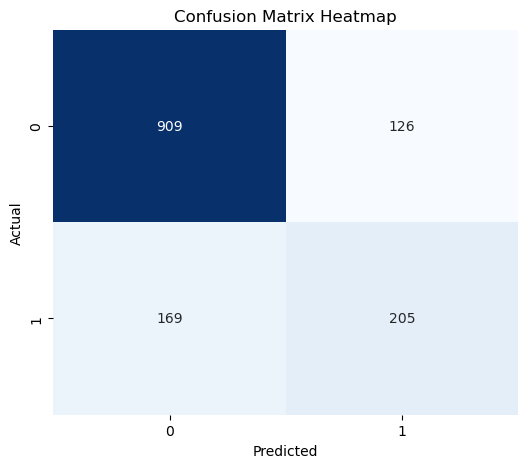

In [5]:
pipeline.evaluate(pipeline.pipeline)

In [6]:
params = {
    "model_XGBClassifier__n_estimators": [100, 200, 300],
    "model_XGBClassifier__max_depth": [3, 5, 7],
    "model_XGBClassifier__learning_rate": [0.01, 0.05, 0.1],
    "model_XGBClassifier__subsample": [0.8, 1.0],
    "model_XGBClassifier__colsample_bytree": [0.8, 1.0]
}

cv = pipeline.cv(params)

In [7]:
print(cv.best_params_)
print(cv.best_score_)

{'model_XGBClassifier__colsample_bytree': 0.8, 'model_XGBClassifier__learning_rate': 0.01, 'model_XGBClassifier__max_depth': 3, 'model_XGBClassifier__n_estimators': 100, 'model_XGBClassifier__subsample': 0.8}
0.7137123745819398


In [8]:
y_pred = cv.predict(pipeline.X_test)

accuracy = accuracy_score(pipeline.y_test, y_pred)
recall = recall_score(pipeline.y_test, y_pred)
f1 = f1_score(pipeline.y_test, y_pred)

models_df = pd.DataFrame({
    'Model': ['XGBoost'],
    'Accuracy': [round(accuracy, 3)],
    'Recall': [round(recall, 3)],
    'F1':[round(f1,3)]
})

models_df.to_csv(PROJECT_ROOT/'data'/'processed'/'model_results.csv', mode="a", index=False, header=False)

In [9]:
models_df = pd.read_csv(PROJECT_ROOT/'data'/'processed'/'model_results.csv')
models_df.head()

,Model,Accuracy,Recall,F1
0,Baseline Model (Logistic Regression),0.751,0.808,0.648
1,Decision Trees,0.753,0.730,0.611
2,RandomForest,0.781,0.690,0.625
3,XGBoost,0.774,0.695,0.621
